# ClassicalDetector Adim Adim Canli Test

Bu notebook, `src/robolig_ai/detection/classical_detector.py` icindeki klasik dedektor akisinin tum asamalarini tek tek gosterir.

## 1) Ortam Hazirligi ve Importlar

Bu adimda notebookun calisacagi temel ortam kurulur.
- Gerekli kutuphaneler import edilir (`cv2`, `numpy`, `matplotlib`, `pandas`).
- `src` ve proje koku `sys.path` icine eklenir, boylece paket import hatalari engellenir.
- Logger seviyesi `DEBUG` yapilir; ara asamalardaki teknik detaylar gorunur olur.

In [ ]:
import sys
import logging
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

logging.basicConfig(level=logging.DEBUG, format="[%(levelname)s] %(message)s")
logger = logging.getLogger("classical-detector-notebook")
logger.setLevel(logging.DEBUG)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR:", SRC_DIR)

## 2) Test Goruntusunu Yukle ve Goster

Bu adimda test girdisi okunur ve ilk kalite kontrolu yapilir.
- `test.png` dosyasi alternatif yollardan bulunur.
- Goruntu `BGR` olarak okunur, goruntuleme icin `RGB`'ye cevrilir.
- Boyut bilgisi yazdirilir; dosya bulunamazsa aciklayici hata firlatilir.

Amac: sonraki adimlara gecmeden once girdinin dogru oldugunu garanti etmek.

In [ ]:
from robolig_ai.detection.classical_detector import ClassicalDetector
from robolig_ai.utils.types import BoundingBox

candidate_paths = [
    PROJECT_ROOT / "src" / "robolig_ai" / "test.png",
    PROJECT_ROOT / "src" / "robolig_ai" / "color" / "test.png",
]

TEST_IMAGE_PATH = None
for p in candidate_paths:
    if p.exists():
        TEST_IMAGE_PATH = p
        break

if TEST_IMAGE_PATH is None:
    raise FileNotFoundError("test.png bulunamadi. Beklenen yollarda yok.")

image_bgr = cv2.imread(str(TEST_IMAGE_PATH))
if image_bgr is None:
    raise RuntimeError(f"Goruntu okunamadi: {TEST_IMAGE_PATH}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
h, w = image_bgr.shape[:2]

print(f"Goruntu: {TEST_IMAGE_PATH}")
print(f"Boyut: {w}x{h}")

plt.figure(figsize=(9, 5))
plt.imshow(image_rgb)
plt.title("Girdi: test.png")
plt.axis("off")
plt.show()

## 3) Dedektor Parametreleri ve Nesne Olusturma

Bu adimda `ClassicalDetector` parametreleri tek noktadan tanimlanir.
- Blur, morfoloji, alan filtreleri, geometri esikleri ve confidence tabani belirlenir.
- Dedektor nesnesi bu parametrelerle olusturulur.

Amac: tum karar mekanizmasini okunur ve degistirilebilir yapmak.

In [3]:
params = {
    "blur_kernel": 5,
    "morph_kernel": 5,
    "min_area": 500,
    "max_area": 100000,
    "min_aspect_ratio": 0.7,
    "max_aspect_ratio": 1.3,
    "min_extent": 0.6,
    "approx_epsilon": 0.04,
    "min_corners": 4,
    "max_corners": 8,
    "base_confidence": 0.6,
}

classical_detector = ClassicalDetector(**params)
print("ClassicalDetector hazir:")
for k, v in params.items():
    print(f"  {k}: {v}")

ClassicalDetector hazir:
  blur_kernel: 5
  morph_kernel: 5
  min_area: 500
  max_area: 100000
  min_aspect_ratio: 0.7
  max_aspect_ratio: 1.3
  min_extent: 0.6
  approx_epsilon: 0.04
  min_corners: 4
  max_corners: 8
  base_confidence: 0.6


## 4) On Isleme: Gaussian Blur ve Gray

Bu adim goruntuyu kontur cikarimina hazirlar.
- Gaussian blur ile gurultu azaltilir.
- Gray donusumu ile tek kanalli, daha stabil bir temsil elde edilir.

Amac: Canny kenar tespitinde yalanci kenarlari azaltmak ve kontur kalitesini arttirmak.

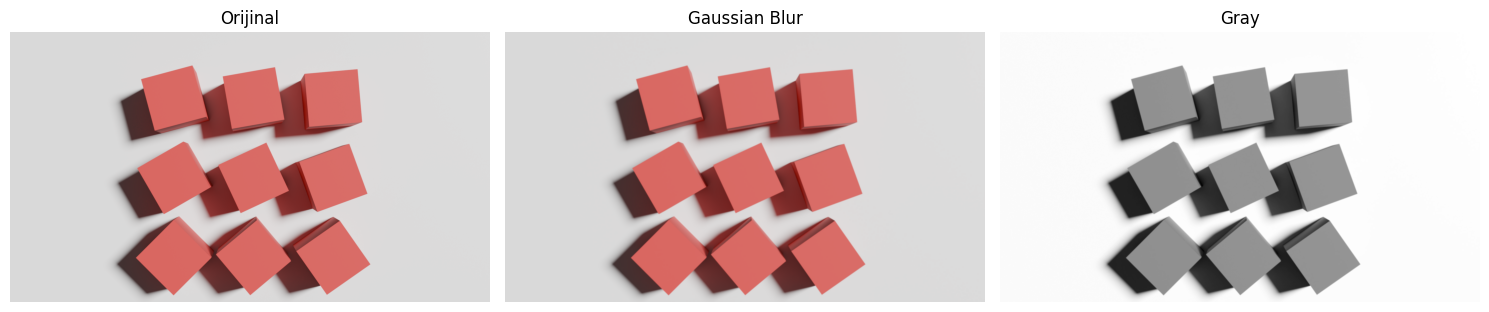

In [4]:
blurred = cv2.GaussianBlur(image_bgr, (params["blur_kernel"], params["blur_kernel"]), 0)
gray = cv2.cvtColor(blurred, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Orijinal")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
axes[1].set_title("Gaussian Blur")
axes[1].axis("off")
axes[2].imshow(gray, cmap="gray")
axes[2].set_title("Gray")
axes[2].axis("off")
plt.tight_layout()
plt.show()

## 5) Kenar Tespiti: Canny

Bu adimda nesne sinirlari kenar haritasina donusturulur.
- `low/high` threshold degerleriyle Canny uygulanir.
- Sonuc ikili (binary) kenar goruntusudur.

Amac: kontur bulma adiminin kullanacagi net sinirlari ortaya cikarmak.

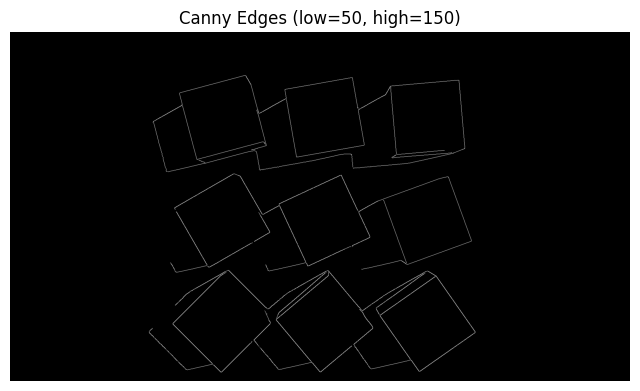

In [5]:
canny_low = 50
canny_high = 150
edges = cv2.Canny(gray, canny_low, canny_high)

plt.figure(figsize=(8, 5))
plt.imshow(edges, cmap="gray")
plt.title(f"Canny Edges (low={canny_low}, high={canny_high})")
plt.axis("off")
plt.show()

## 6) Morfolojik Closing (Kenar Bosluklarini Kapatma)

Bu adimda kenar haritasindaki kopukluklar birlestirilir.
- `MORPH_CLOSE` ile kucuk bosluklar kapanir.
- Kenar cizgileri daha butun hale gelir.

Amac: kontur bulma sirasinda tek parca nesne sinirlari elde etmek.

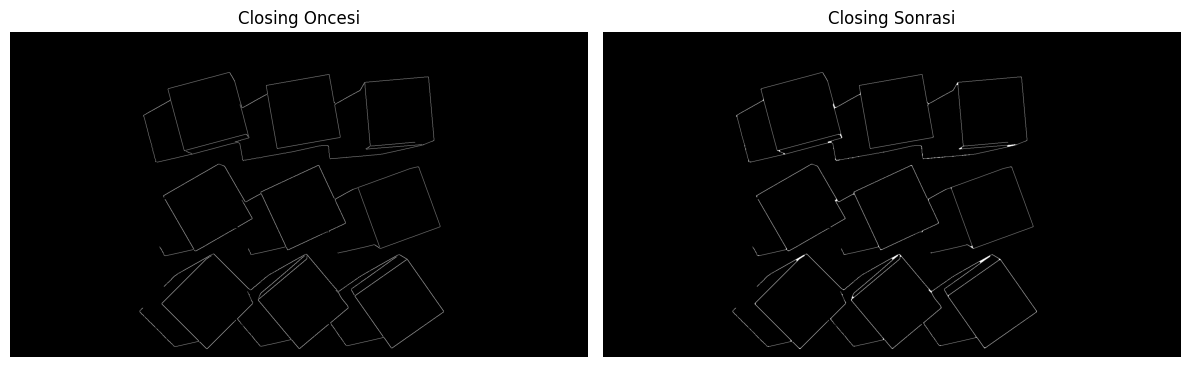

In [6]:
kernel = np.ones((params["morph_kernel"], params["morph_kernel"]), np.uint8)
edges_closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(edges, cmap="gray")
axes[0].set_title("Closing Oncesi")
axes[0].axis("off")
axes[1].imshow(edges_closed, cmap="gray")
axes[1].set_title("Closing Sonrasi")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 7) Kontur Bulma ve Ham Konturlari Gorsellestirme

Bu adimda tum dis konturlar ham olarak cikartilir.
- `findContours(..., RETR_EXTERNAL, ...)` ile sadece en dis konturlar alinir.
- Ham konturlar goruntu uzerine cizdirilerek adaylarin yayilimi gorulur.

Amac: filtreleme oncesi ham aday havuzunu gormek.

Toplam ham kontur sayisi: 7


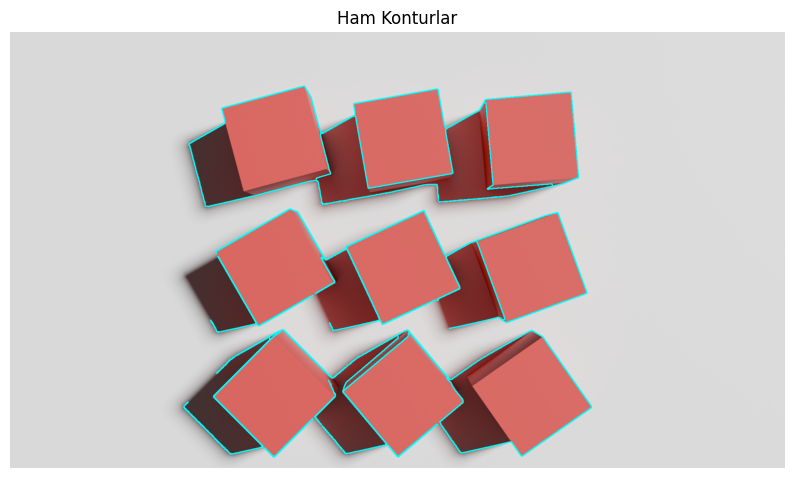

In [7]:
contours, _ = cv2.findContours(edges_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"Toplam ham kontur sayisi: {len(contours)}")

contour_vis = image_rgb.copy()
cv2.drawContours(contour_vis, contours, -1, (0, 255, 255), 2)

plt.figure(figsize=(10, 6))
plt.imshow(contour_vis)
plt.title("Ham Konturlar")
plt.axis("off")
plt.show()

## 8) Kontur Filtreleme Mantigi (_evaluate_contour Adimlari)

Bu adimda her kontur icin karar agaci tek tek uygulanir.
- Alan filtresi (`min_area`, `max_area`)
- En-boy orani filtresi (`aspect_ratio`)
- Doluluk filtresi (`extent`)
- Kose sayisi filtresi (`approxPolyDP`)

Her kontur icin `accepted/rejected` nedeni tabloda yazdirilir.
Amac: dedektorun neden bir aday kabul ettigini veya eledigini seffaflastirmak.

,idx,area,aspect_ratio,extent,corners,confidence,reason
0,0,119.5,1.271,0.010,4,None,rejected: area
1,1,78.5,0.477,0.013,6,None,rejected: area
2,2,73980.0,3.199,0.232,2,None,rejected: aspect_ratio
3,3,74.5,1.842,0.007,2,None,rejected: area
4,4,116.5,0.612,0.005,5,None,rejected: area
5,5,46682.0,3.050,0.168,5,None,rejected: aspect_ratio
6,6,161293.0,3.234,0.558,3,None,rejected: area


Kabul edilen aday sayisi: 0


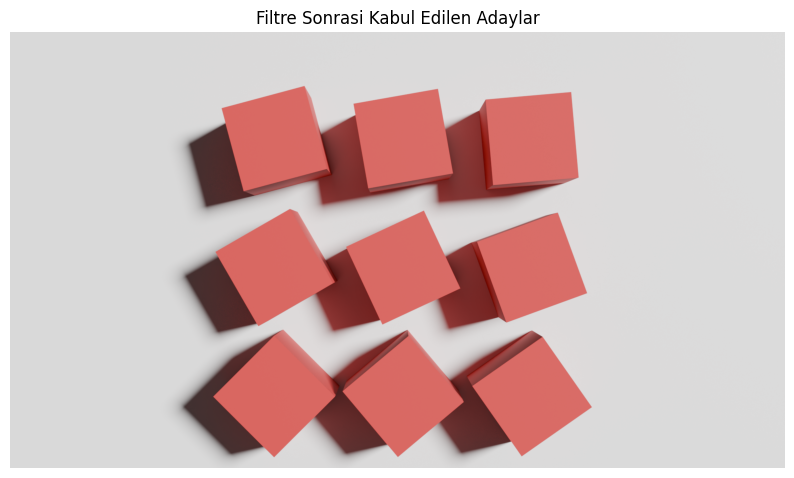

In [8]:
rows = []
accepted = []

for i, contour in enumerate(contours):
    area = cv2.contourArea(contour)
    x, y, w_box, h_box = cv2.boundingRect(contour)
    aspect_ratio = float(w_box) / h_box if h_box > 0 else 0.0
    extent = area / (w_box * h_box) if (w_box * h_box) > 0 else 0.0

    perimeter = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, params["approx_epsilon"] * perimeter, True)
    num_corners = len(approx)

    reason = "accepted"
    if area < params["min_area"] or area > params["max_area"]:
        reason = "rejected: area"
    elif aspect_ratio < params["min_aspect_ratio"] or aspect_ratio > params["max_aspect_ratio"]:
        reason = "rejected: aspect_ratio"
    elif extent < params["min_extent"]:
        reason = "rejected: extent"
    elif num_corners < params["min_corners"] or num_corners > params["max_corners"]:
        reason = "rejected: corners"

    confidence = None
    if reason == "accepted":
        confidence = classical_detector._compute_confidence(
            aspect_ratio=aspect_ratio,
            extent=extent,
            num_corners=num_corners,
            area=area,
        )
        accepted.append((x, y, w_box, h_box, confidence))

    rows.append(
        {
            "idx": i,
            "area": round(area, 2),
            "aspect_ratio": round(aspect_ratio, 3),
            "extent": round(extent, 3),
            "corners": num_corners,
            "confidence": None if confidence is None else round(confidence, 3),
            "reason": reason,
        }
    )

report_df = pd.DataFrame(rows)
display(report_df)
print("Kabul edilen aday sayisi:", len(accepted))

accepted_vis = image_rgb.copy()
for x, y, w_box, h_box, conf in accepted:
    cv2.rectangle(accepted_vis, (x, y), (x + w_box, y + h_box), (0, 255, 0), 2)
    cv2.putText(
        accepted_vis,
        f"cube {conf:.2f}",
        (x, max(15, y - 7)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (0, 255, 0),
        2,
    )

plt.figure(figsize=(10, 6))
plt.imshow(accepted_vis)
plt.title("Filtre Sonrasi Kabul Edilen Adaylar")
plt.axis("off")
plt.show()

## 9) detect() ile Nihai Cikti ve Karsilastirma

Bu adimda dedektorun gercek `detect()` cikisi alinip gorsellestirilir.
- Final bbox'lar ve confidence degerleri yazdirilir.
- Sonuc, goruntu uzerinde anotasyonla gosterilir.

Amac: manuel ara-adim analizi ile sinifin resmi cikisinin tutarliligini karsilastirmak.

[DEBUG] Klasik dedektör: 0 küp adayı bulundu


detect() tespit sayisi: 0
Siniflar: []
Confidences: []


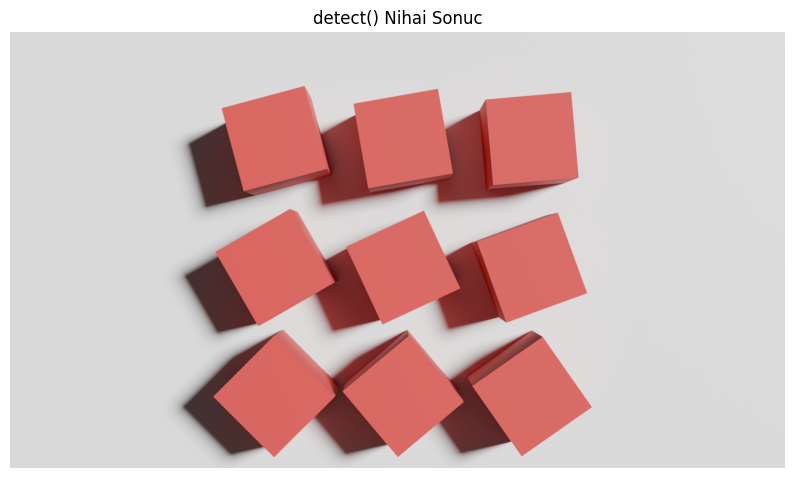

In [9]:
det_out = classical_detector.detect(image_bgr)

print(f"detect() tespit sayisi: {len(det_out)}")
print("Siniflar:", det_out.class_names)
print("Confidences:", [round(c, 3) for c in det_out.confidences])

final_vis = image_rgb.copy()
for bbox, conf in zip(det_out.bboxes, det_out.confidences):
    cv2.rectangle(final_vis, (bbox.x1, bbox.y1), (bbox.x2, bbox.y2), (255, 255, 0), 2)
    cv2.putText(
        final_vis,
        f"cube {conf:.2f}",
        (bbox.x1, max(15, bbox.y1 - 8)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (255, 255, 0),
        2,
    )

plt.figure(figsize=(10, 6))
plt.imshow(final_vis)
plt.title("detect() Nihai Sonuc")
plt.axis("off")
plt.show()

## 10) Parametre Duyarliligi (Slider ile Canli Deney)

Bu adimda kritik parametreler slider ile canli degistirilir.
- `blur_kernel`, `min_area`, `min_extent`, `approx_epsilon`
- Her degisiklikte `detect()` tekrar calisir ve tespit sayisi guncellenir.

Amac: dedektorun parametre hassasiyetini hizlica kesfetmek ve en stabil ayarlari bulmak.

In [10]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    out = widgets.Output()

    s_blur = widgets.IntSlider(value=5, min=3, max=11, step=2, description="blur")
    s_min_area = widgets.IntSlider(value=500, min=50, max=5000, step=50, description="min_area")
    s_min_extent = widgets.FloatSlider(value=0.6, min=0.2, max=1.0, step=0.02, description="extent")
    s_eps = widgets.FloatSlider(value=0.04, min=0.005, max=0.12, step=0.005, description="epsilon")

    def _update(*_):
        with out:
            clear_output(wait=True)
            det = ClassicalDetector(
                blur_kernel=int(s_blur.value),
                morph_kernel=params["morph_kernel"],
                min_area=int(s_min_area.value),
                max_area=params["max_area"],
                min_aspect_ratio=params["min_aspect_ratio"],
                max_aspect_ratio=params["max_aspect_ratio"],
                min_extent=float(s_min_extent.value),
                approx_epsilon=float(s_eps.value),
                min_corners=params["min_corners"],
                max_corners=params["max_corners"],
                base_confidence=params["base_confidence"],
            )
            out_det = det.detect(image_bgr)
            print(f"Tespit sayisi: {len(out_det)}")
            print("Confidences:", [round(c, 3) for c in out_det.confidences])

    for s in [s_blur, s_min_area, s_min_extent, s_eps]:
        s.observe(_update, names="value")

    display(widgets.VBox([s_blur, s_min_area, s_min_extent, s_eps]), out)
    _update()
except Exception as e:
    print("ipywidgets kullanilamadi:", e)
    print("Kurulum icin: pip install ipywidgets")

ipywidgets kullanilamadi: No module named 'ipywidgets'
Kurulum icin: pip install ipywidgets


## 11) Ara Sonuclari Kaydet ve Debug Ozeti

Bu adim calismayi tekrar uretilebilir hale getirir.
- Ara goruntuler (`blur`, `gray`, `edges`, `closed`, `final`) `outputs/` klasorune kaydedilir.
- DEBUG loglari acik tutulur.

Amac: sonradan analiz, raporlama ve regresyon karsilastirmasi icin kalici artefaktlar olusturmak.

In [ ]:
logger.debug("Classical notebook debug modu aktif")

outputs_dir = PROJECT_ROOT / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)

cv2.imwrite(str(outputs_dir / "classical_step_1_blurred.png"), blurred)
cv2.imwrite(str(outputs_dir / "classical_step_2_gray.png"), gray)
cv2.imwrite(str(outputs_dir / "classical_step_3_edges.png"), edges)
cv2.imwrite(str(outputs_dir / "classical_step_4_edges_closed.png"), edges_closed)
cv2.imwrite(str(outputs_dir / "classical_step_5_final_vis.png"), cv2.cvtColor(final_vis, cv2.COLOR_RGB2BGR))

print(f"Ara ciktilar kaydedildi: {outputs_dir}")
print("Notebook hucreleri sirayla calistirildiginda ayni sonuclar tekrar uretilebilir.")

## Ozet

Bu notebook, `ClassicalDetector` akisindaki tum teknik adimlari acik ve gozlenebilir hale getirir:
- On isleme ve kenar cikarma,
- Kontur bulma ve filtreleme karar mantigi,
- Confidence hesaplama,
- Final `detect()` sonucu,
- Parametre duyarliligi ve debug kayitlari.

Boylece hem algoritma mantigi hem de pratik tuning sureci tek bir calisma dosyasi uzerinden izlenebilir.